In [1]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs import CLASSES
from shared.pacs_protocol import build_loaders
from task2.backbones.backbone import PACSModel
from task2.training.train_loop import train_model
from task2.methods.dan import DAN

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE = dict(seed=6304, num_classes=7,
            batch_per_source=8, target_batch=24, eval_batch=64, num_workers=0,
            max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4, amp=False)
LAMBDAS = [0.1, 10.0]        # lambda=1 is the main DAN run, already trained
DATA_ROOT = '../../datasets/PACS'

In [2]:
# --- Cell 2: loaders ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits, batch_per_source=8, target_batch=24,
                        eval_batch=64, num_workers=0, seed=6304)
print(f"steps/epoch={loaders['steps_per_epoch']}")

steps/epoch=203


In [3]:
# --- Cell 2b: memory check ---
import gc, torch
gc.collect(); torch.cuda.empty_cache()
free, total = torch.cuda.mem_get_info()
print(f"GPU free {free/1e9:.2f} GB of {total/1e9:.2f} GB")

GPU free 7.45 GB of 8.59 GB


In [4]:
# --- Cell 3: train the two extra lambdas ---
runs = {}
for lam in LAMBDAS:
    cfg = dict(BASE, lambda_mmd=lam)
    tag = f"dan_lam{lam}"
    print(f"\n===== {tag} =====")
    set_seed(6304)
    loaders = build_loaders(DATA_ROOT, splits,      # rebuild per lambda: every run must
                            batch_per_source=cfg['batch_per_source'],   # start from the same
                            target_batch=cfg['target_batch'],           # first batch
                            eval_batch=cfg['eval_batch'],
                            num_workers=cfg['num_workers'], seed=cfg['seed'])
    model = PACSModel(num_classes=7).to(device)
    method = DAN(cfg)
    out = train_model(model, method, loaders, cfg, device,
                      ckpt_path=f'../../datasets/cache/task2_{tag}.pt')
    runs[lam] = {'config': cfg, 'best_epoch': out['best_epoch'],
                 'best_mean_macro_f1': out['best_mean_macro_f1'],
                 'source_val_at_best': out['source_val_at_best'],
                 'minutes': out['minutes'], 'history': out['history']}
    print(tag, out['best_epoch'], round(out['best_mean_macro_f1'], 4))


===== dan_lam0.1 =====
ep01 loss_total=0.5857 loss_cls=0.5501 loss_mmd=0.3561 train_acc=0.8144 | val photo=0.881 art_painting=0.818 cartoon=0.882 mean_f1=0.8602 | 49s
ep02 loss_total=0.2263 loss_cls=0.2011 loss_mmd=0.2529 train_acc=0.9329 | val photo=0.959 art_painting=0.855 cartoon=0.921 mean_f1=0.9119 | 100s
ep03 loss_total=0.1883 loss_cls=0.1655 loss_mmd=0.2280 train_acc=0.9442 | val photo=0.917 art_painting=0.795 cartoon=0.906 mean_f1=0.8728 | 150s
ep04 loss_total=0.1740 loss_cls=0.1520 loss_mmd=0.2199 train_acc=0.9470 | val photo=0.937 art_painting=0.920 cartoon=0.929 mean_f1=0.9288 | 199s
ep05 loss_total=0.1002 loss_cls=0.0786 loss_mmd=0.2168 train_acc=0.9750 | val photo=0.964 art_painting=0.893 cartoon=0.918 mean_f1=0.9251 | 251s
ep06 loss_total=0.0939 loss_cls=0.0724 loss_mmd=0.2141 train_acc=0.9739 | val photo=0.961 art_painting=0.865 cartoon=0.951 mean_f1=0.9258 | 303s
ep07 loss_total=0.0865 loss_cls=0.0657 loss_mmd=0.2084 train_acc=0.9784 | val photo=0.958 art_painting=0.90

In [5]:
# --- Cell 4: evaluate all three lambdas on target (labels only at this stage) ---
from task2.evaluations.metrics import evaluate_loader, evaluate_source_val
from task2.evaluations.domain_separability import domain_separability, collect_features
from task2.evaluations.class_analysis import per_class_table, predicted_distribution

CKPTS = {0.1: '../../datasets/cache/task2_dan_lam0.1.pt',
         1.0: '../../datasets/cache/task2_dan.pt',           # the main run
         10.0: '../../datasets/cache/task2_dan_lam10.0.pt'}

def l2n(a):
    return a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)

sweep = {}
for lam, path in CKPTS.items():
    ck = torch.load(path, map_location=device, weights_only=False)
    model = PACSModel(num_classes=7).to(device)
    model.load_state_dict(ck['model'])

    sv = evaluate_source_val(model, loaders['source_val'], device)
    tg = evaluate_loader(model, loaders['target_eval'], device, collect_features=True)
    src_f = np.concatenate([collect_features(model, ld, device)[0]
                            for ld in loaders['source_val'].values()])

    sep = domain_separability(src_f, tg['features'], seed=6304)
    sep_n = domain_separability(l2n(src_f), l2n(tg['features']), seed=6304)

    sweep[lam] = {
        'best_epoch': ck['best_epoch'],
        'src_mean_f1': sv['mean_macro_f1'], 'src_mean_acc': sv['mean_accuracy'],
        'src_per_domain': sv['per_domain'],
        'tgt_acc': tg['accuracy'], 'tgt_f1': tg['macro_f1'],
        'separability': sep['separability'], 'separability_norm': sep_n['separability'],
        'feat_norm_src': float(np.linalg.norm(src_f, axis=1).mean()),
        'feat_norm_tgt': float(np.linalg.norm(tg['features'], axis=1).mean()),
        'per_class': per_class_table(tg['preds'], tg['labels'], CLASSES),
        'pred_counts': predicted_distribution(tg['preds'], CLASSES),
        'final_mmd': ck['config'].get('lambda_mmd'),
    }
    print(f"lam={lam:<5} src_f1={sv['mean_macro_f1']:.4f}  tgt_acc={tg['accuracy']:.4f}  "
          f"tgt_f1={tg['macro_f1']:.4f}  sep={sep['separability']:.4f}  "
          f"sep_norm={sep_n['separability']:.4f}  |f|={np.linalg.norm(src_f,axis=1).mean():.1f}")

lam=0.1   src_f1=0.9482  tgt_acc=0.7266  tgt_f1=0.6766  sep=0.9519  sep_norm=0.8036  |f|=35.0
lam=1.0   src_f1=0.9412  tgt_acc=0.6281  tgt_f1=0.5810  sep=0.8626  sep_norm=0.6992  |f|=15.9
lam=10.0  src_f1=0.0507  tgt_acc=0.0407  tgt_f1=0.0112  sep=0.6621  sep_norm=0.6621  |f|=0.2


In [6]:
# --- Cell 5: table ---
import pandas as pd
rows = [{'lambda': lam, 'best_epoch': s['best_epoch'],
         'src_mean_f1': round(s['src_mean_f1'], 4),
         'tgt_acc': round(s['tgt_acc'], 4), 'tgt_f1': round(s['tgt_f1'], 4),
         'separability': round(s['separability'], 4),
         'sep_normalised': round(s['separability_norm'], 4),
         'feat_norm_src': round(s['feat_norm_src'], 1)}
        for lam, s in sorted(sweep.items())]
print(pd.DataFrame(rows).to_string(index=False))

print('\npredicted-label counts (true support: house 80, person 160)')
for lam, s in sorted(sweep.items()):
    print(f"  lam={lam:<5} house={s['pred_counts']['house']:5d}  "
          f"person={s['pred_counts']['person']:5d}  "
          f"giraffe={s['pred_counts']['giraffe']:5d}")

 lambda  best_epoch  src_mean_f1  tgt_acc  tgt_f1  separability  sep_normalised  feat_norm_src
    0.1          13       0.9482   0.7266  0.6766        0.9519          0.8036           35.0
    1.0           7       0.9412   0.6281  0.5810        0.8626          0.6992           15.9
   10.0           1       0.0507   0.0407  0.0112        0.6621          0.6621            0.2

predicted-label counts (true support: house 80, person 160)
  lam=0.1   house=  345  person=  553  giraffe=  686
  lam=1.0   house=  489  person=  781  giraffe=  566
  lam=10.0  house=    0  person= 3929  giraffe=    0


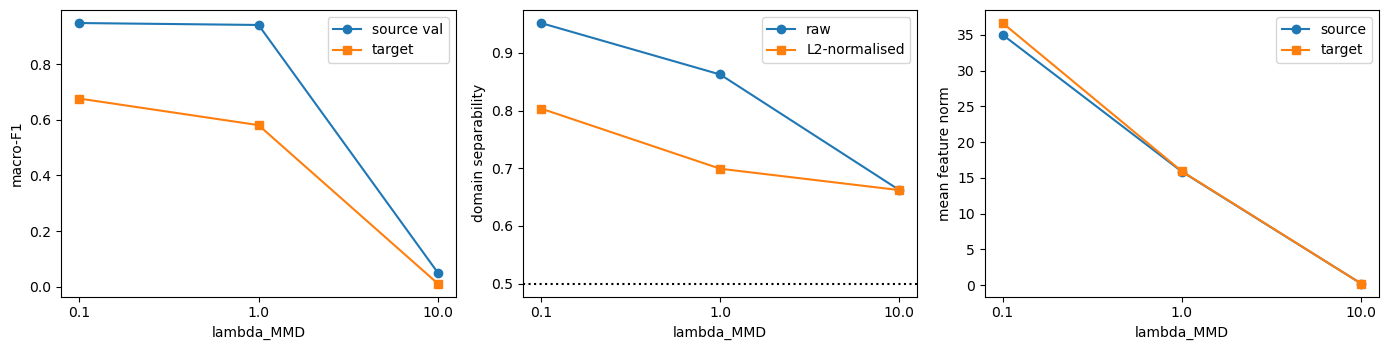

In [7]:
# --- Cell 6: figure — alignment pressure vs everything it affects ---
import matplotlib.pyplot as plt
lams = sorted(sweep)
x = np.arange(len(lams))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(x, [sweep[l]['src_mean_f1'] for l in lams], marker='o', label='source val')
ax[0].plot(x, [sweep[l]['tgt_f1'] for l in lams], marker='s', label='target')
ax[0].set_ylabel('macro-F1'); ax[0].legend()
ax[1].plot(x, [sweep[l]['separability'] for l in lams], marker='o', label='raw')
ax[1].plot(x, [sweep[l]['separability_norm'] for l in lams], marker='s', label='L2-normalised')
ax[1].axhline(0.5, ls=':', c='k'); ax[1].set_ylabel('domain separability'); ax[1].legend()
ax[2].plot(x, [sweep[l]['feat_norm_src'] for l in lams], marker='o', label='source')
ax[2].plot(x, [sweep[l]['feat_norm_tgt'] for l in lams], marker='s', label='target')
ax[2].set_ylabel('mean feature norm'); ax[2].legend()
for a in ax:
    a.set_xticks(x); a.set_xticklabels([str(l) for l in lams]); a.set_xlabel('lambda_MMD')
plt.tight_layout(); plt.savefig('../../report/figures/task2_lambda_study.png', dpi=200)
plt.show()

In [8]:
# --- Cell 7: save ---
save_results({'step': 'lambda_study', 'seed': 6304, 'method': 'dan',
              'lambdas': {str(k): {kk: vv for kk, vv in v.items()}
                          for k, v in sweep.items()},
              'training': {str(k): v for k, v in runs.items()}},
             '../results/lambda_study.json')
print('saved')

saved
